In [2]:
%pip install nba_api

Defaulting to user installation because normal site-packages is not writeable
  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
Using cached requests-2.32.4-py3-none-any.whl (64 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ----------------------------------- ---- 9.7/11.0 MB 50.2 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 42.9 MB/s eta 0:00:00

  Attempting uninstall: requests

    Found existing installation: requests 2.32.2

    Uninstalling requests-2.32.2:

      Successfully uninstalled requests-2.32.2

   ---------------------------------------- 0/3 [requests]
  Attempting uninstall: pandas
   ---------------------------------------- 0/3 [requests]
    Found existing installation: pandas 2.1.4
   ---------------------------------------- 0/3 [requests]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
    Uninstalling pandas-2.1.4:
   -----

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
azure-core 1.34.0 requires typing-extensions>=4.6.0, which is not installed.
azure-identity 1.21.0 requires typing-extensions>=4.0.0, which is not installed.
azure-keyvault-secrets 4.9.0 requires typing-extensions>=4.0.1, which is not installed.
dash 2.18.1 requires typing-extensions>=4.1.1, which is not installed.
datasets 3.5.0 requires huggingface-hub>=0.24.0, which is not installed.
evaluate 0.4.3 requires huggingface-hub>=0.7.0, which is not installed.
google-api-core 2.24.2 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.19.5, which is not installed.
google-generativeai 0.8.4 requires protobuf, which is not installed.
google-generativeai 0.8.4 requires typing-extensions, which is not 

In [ ]:
from nba_api.stats.endpoints import leaguedashplayerclutch
import pandas as pd

# Function to fetch clutch stats for a given season and add a season column
def fetch_clutch_stats(season):
    clutch_stats = leaguedashplayerclutch.LeagueDashPlayerClutch(season=season)
    clutch_stats_df = clutch_stats.get_data_frames()[0]
    clutch_stats_df['SEASON'] = season  # Adding a season column
    return clutch_stats_df

# List of seasons to analyze
seasons = ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23','2023-24']

# Concatenating data for all seasons into a single DataFrame
all_seasons_clutch_stats = pd.concat([fetch_clutch_stats(season) for season in seasons])

# Adding a column to flag the current season vs previous seasons
current_season = '2023-24'
all_seasons_clutch_stats['SEASON_TYPE'] = all_seasons_clutch_stats['SEASON'].apply(lambda x: 'Current Season' if x == current_season else 'Previous 5 Seasons')

# Displaying the first few rows of the combined DataFrame
print(all_seasons_clutch_stats[['SEASON', 'SEASON_TYPE', 'PLAYER_NAME', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'AST', 'PTS', 'REB', 'TOV', 'STL', 'BLK', 'PF']].head())


    SEASON         SEASON_TYPE PLAYER_NAME  FG_PCT  FG3_PCT  FT_PCT  AST  PTS  \
0  2018-19  Previous 5 Seasons        None   0.444    0.500   0.833    0   15   
1  2018-19  Previous 5 Seasons        None   0.500    0.000   1.000    1    5   
2  2018-19  Previous 5 Seasons        None   0.500    0.000   0.000    1    2   
3  2018-19  Previous 5 Seasons        None   0.333    0.333   0.750    0    6   
4  2018-19  Previous 5 Seasons        None   0.000    0.000   0.500    1    1   

   REB  TOV  STL  BLK  PF  
0    3    1    1    0   1  
1    1    2    1    0   1  
2    2    1    0    1   2  
3    0    0    0    0   1  
4    0    0    0    0   0  


: 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = all_seasons_clutch_stats

# Example for generating a bar graph for Top 10 Players in Clutch Points (PTS)
def create_bar_plot(data, category, title, color):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=data, x=category, y='PLAYER_NAME', palette=color)
    plt.title(title)
    plt.xlabel(category)
    plt.ylabel('Player Name')
    plt.show()


In [5]:
import matplotlib.ticker as ticker

# Function to create scatter plots with player names and specified axis limits
def create_scatter_plot_with_names_and_limits(data, x_metric, y_metric, title, x_min, y_min):
    plt.figure(figsize=(12, 8))
    plot = sns.scatterplot(data=data, x=x_metric, y=y_metric)
    
    # Adding player names to the points
    for line in range(0, data.shape[0]):
        plot.text(data[x_metric].iloc[line]+0.001, data[y_metric].iloc[line], 
                  data['PLAYER_NAME'].iloc[line], horizontalalignment='left', 
                  size='small', color='black', weight='semibold')
    
    # Setting axis limits
    plt.xlim(x_min, 1)
    plt.ylim(y_min, 1)

    plt.title(title)
    plt.xlabel(f'{x_metric} (2023-24 Season)')
    plt.ylabel(f'{y_metric} (Previous Seasons Average)')
    plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Adding a reference line
    plt.gca().xaxis.set_major_formatter(ticker.PercentFormatter(1))
    plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1))
    plt.show()


In [7]:
all_seasons_clutch_stats.head()

,GROUP_SET,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,...,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,SEASON,SEASON_TYPE
0,Players,203932,Aaron Gordon,Aaron,1610612753,ORL,23.0,43,22,21,...,401,153,104,94,75,25,25,78,2018-19,Previous 5 Seasons
1,Players,1628988,Aaron Holiday,Aaron,1610612754,IND,22.0,4,2,2,...,140,329,327,289,405,203,25,372,2018-19,Previous 5 Seasons
2,Players,1627846,Abdel Nader,Abdel,1610612760,OKC,25.0,3,2,1,...,1,329,315,194,338,203,25,323,2018-19,Previous 5 Seasons
3,Players,201143,Al Horford,Al,1610612738,BOS,33.0,38,22,16,...,390,60,51,26,34,53,12,38,2018-19,Previous 5 Seasons
4,Players,202329,Al-Farouq Aminu,Al-Farouq,1610612757,POR,28.0,35,22,13,...,302,77,83,25,63,53,25,62,2018-19,Previous 5 Seasons


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


In [ ]:
# Replace 'your_data.csv' with the path to your data file
all_seasons_clutch_stats = pd.read_csv(r'C:\Users\Ben\OneDrive\Documents\Medium_Story_Dashboard\all_seasons_clutch_stats.csv')

In [10]:
latest_season = all_seasons_clutch_stats['SEASON'].max()
latest_season 

'2023-24'

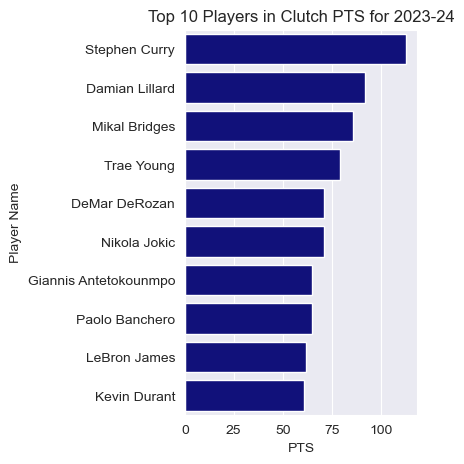

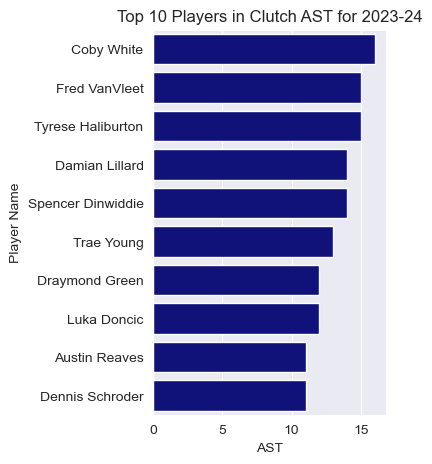

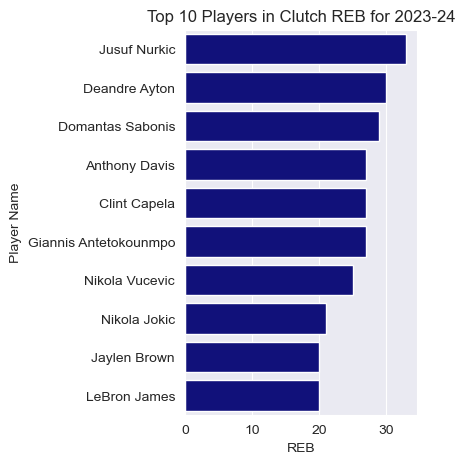

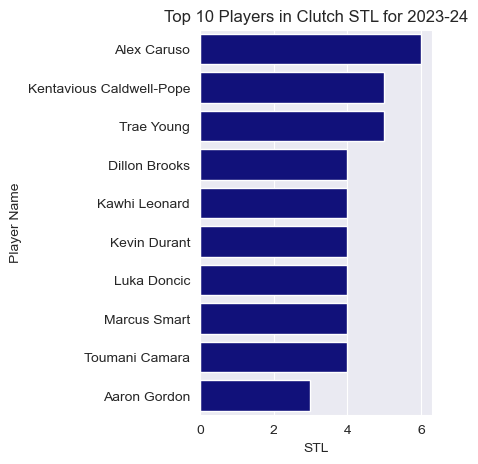

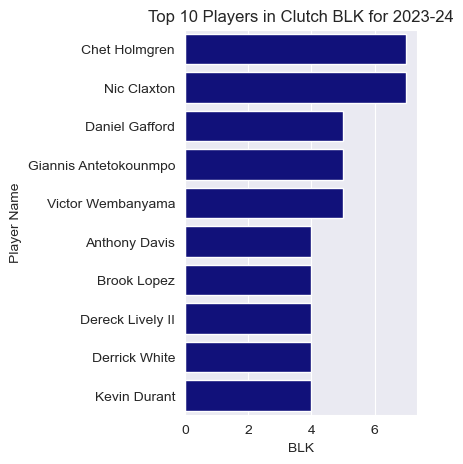

In [13]:
def create_bar_plot(data, category, title):
    plt.figure(figsize=(3, 5))
    sns.set_style("darkgrid")
    sns.barplot(data=data, x=category, y='PLAYER_NAME', color='darkblue')
    plt.title(title)
    plt.xlabel(category)
    plt.ylabel('Player Name')
    plt.show()

# Filter the data for the latest season
latest_season_data = all_seasons_clutch_stats[all_seasons_clutch_stats['SEASON'] == latest_season]

# Find the top 10 players in PTS, AST, REB, STL, BLK (if available)
metrics = ['PTS', 'AST', 'REB', 'STL', 'BLK']
for metric in metrics:
    if metric in latest_season_data.columns:
        top_players = latest_season_data.nlargest(10, metric)[['PLAYER_NAME', metric]]
        create_bar_plot(top_players, metric, f'Top 10 Players in Clutch {metric} for {latest_season}')


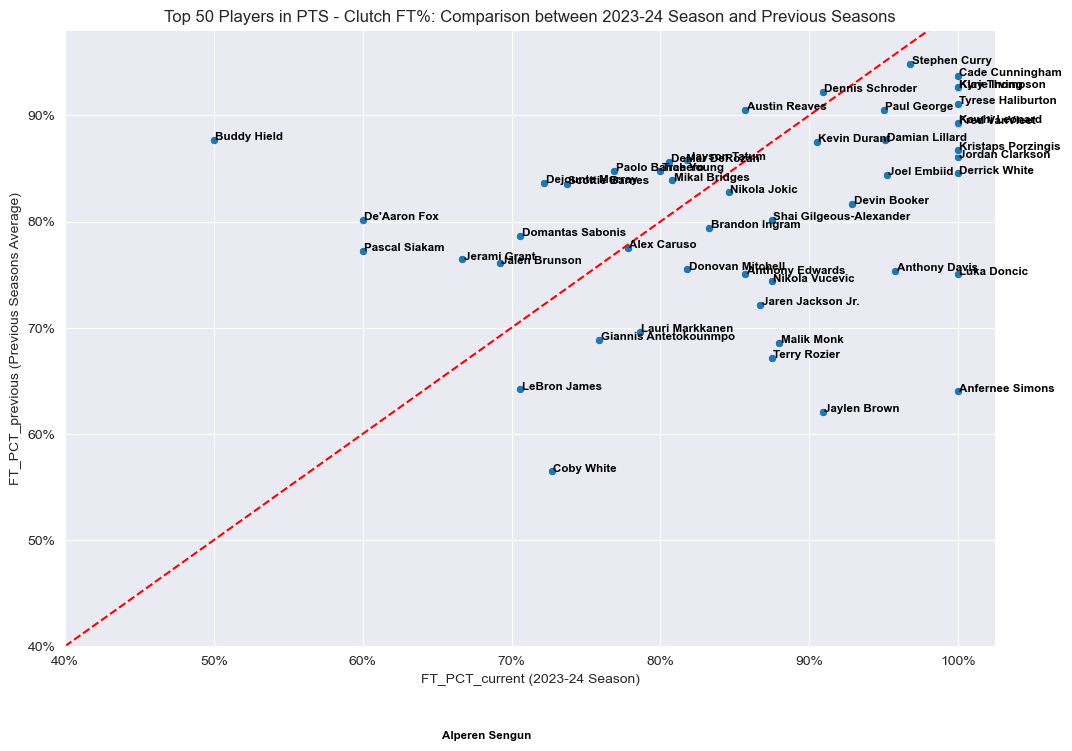

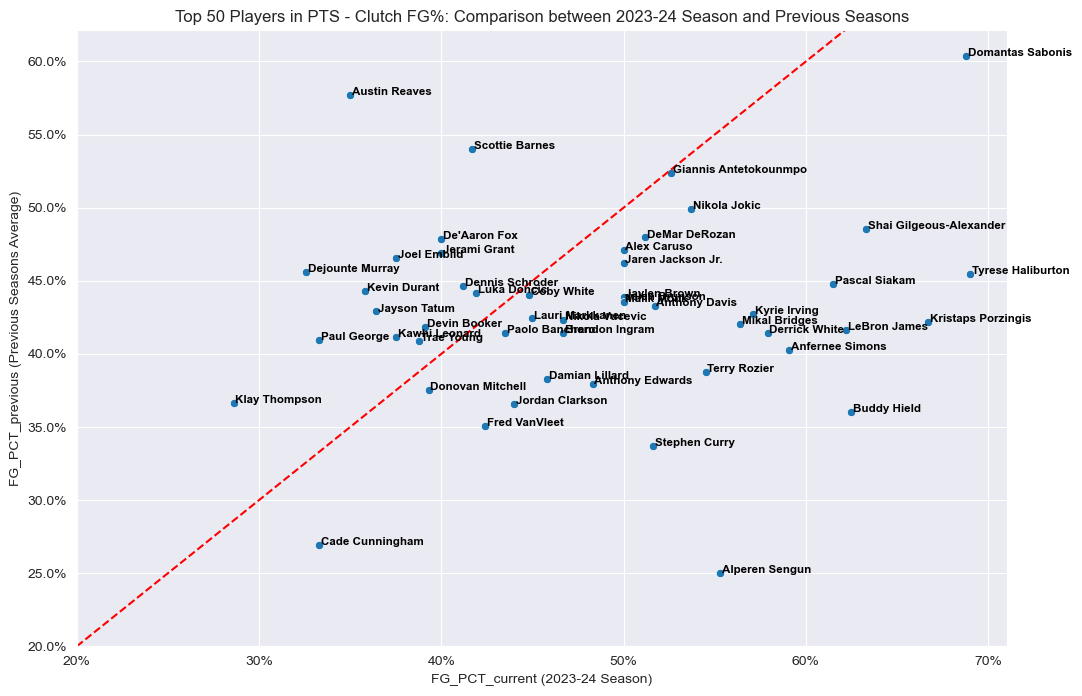

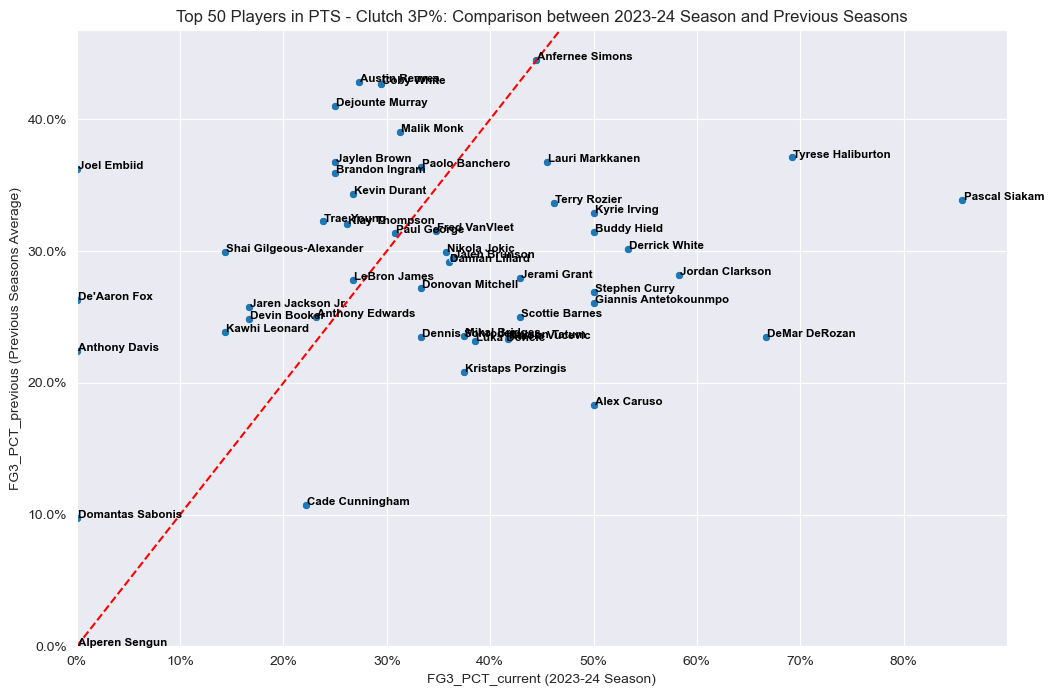

In [23]:
def create_scatter_plot_with_names_and_min_limits(data, x_metric, y_metric, title, x_min, y_min):
    plt.figure(figsize=(12, 8))
    plot = sns.scatterplot(data=data, x=x_metric, y=y_metric)
    
    # Adding player names to the points
    for line in range(0, data.shape[0]):
        plot.text(data[x_metric].iloc[line]+0.001, data[y_metric].iloc[line], 
                  data['PLAYER_NAME'].iloc[line], horizontalalignment='left', 
                  size='small', color='black', weight='semibold')
    
    # Setting minimum axis limits
    plt.xlim(left=x_min)
    plt.ylim(bottom=y_min)

    plt.title(title)
    plt.xlabel(f'{x_metric} (2023-24 Season)')
    plt.ylabel(f'{y_metric} (Previous Seasons Average)')
    plt.axline((0, 0), slope=1, color='red', linestyle='--')
    plt.gca().xaxis.set_major_formatter(ticker.PercentFormatter(1))
    plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1))
    plt.show()

# Creating scatter plots with specific minimum limits
create_scatter_plot_with_names_and_min_limits(merged_ft_pct, 'FT_PCT_current', 'FT_PCT_previous', 'Top 50 Players in PTS - Clutch FT%: Comparison between 2023-24 Season and Previous Seasons', 0.4, 0.4)
create_scatter_plot_with_names_and_min_limits(merged_fg_pct, 'FG_PCT_current', 'FG_PCT_previous', 'Top 50 Players in PTS - Clutch FG%: Comparison between 2023-24 Season and Previous Seasons', 0.2, 0.2)
create_scatter_plot_with_names_and_min_limits(merged_fg3_pct, 'FG3_PCT_current', 'FG3_PCT_previous', 'Top 50 Players in PTS - Clutch 3P%: Comparison between 2023-24 Season and Previous Seasons', 0, 0)
